## Marker gene identification with COSG

##### Setting basics

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
sc.set_figure_params(dpi=80,dpi_save=300, color_map='Spectral_r',facecolor='white')
from matplotlib import rcParams
# To modify the default figure size, use rcParams.
rcParams['figure.figsize'] = 4, 4
rcParams['font.sans-serif'] = "Arial"
rcParams['font.family'] = "Arial"
sc.settings.verbosity = 3
sc.logging.print_header()

scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.21.6 scipy==1.7.3 pandas==1.4.4 scikit-learn==1.1.2 statsmodels==0.13.2 python-igraph==0.10.4 louvain==0.7.1 pynndescent==0.5.11


##### Setting colors

In [2]:
### Palette
scane_color=["#e6194b","#3cb44b","#ffe119",
"#4363d8","#f58231","#911eb4",
"#46f0f0","#f032e6","#bcf60c",
"#fabebe","#008080","#e6beff",
"#9a6324",
             "#800000",
"#aaffc3","#808000","#ffd8b1",
"#000075","#808080"
            ]
import seaborn as sns
self_palette2=sns.color_palette(np.hstack((scane_color,sc.pl.palettes.godsnot_102)))

# https://matplotlib.org/3.1.0/tutorials/colors/colormap-manipulation.html#sphx-glr-tutorials-colors-colormap-manipulation-py
# # https://gree2.github.io/python/2015/05/06/python-seaborn-tutorial-choosing-color-palettes
from matplotlib import cm
from matplotlib import colors, colorbar
cmap_own = cm.get_cmap('magma_r', 256)
newcolors = cmap_own(np.linspace(0,0.75 , 256))
Greys = cm.get_cmap('Greys_r', 256)
newcolors[:10, :] = Greys(np.linspace(0.8125, 0.8725, 10))
pos_cmap = colors.ListedColormap(newcolors)
di_cmap=sns.diverging_palette(138,359,s=72,l=50,sep=27,n=15,as_cmap=True)

##### Setting paths

In [3]:
save_dir='/n/scratch/users/m/mid166/Result/single-cell/Methods/COSG/COSG_tutorial'
sc.settings.figdir = save_dir
prefix='COSG_tutorial_SEA-AD'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
sc.set_figure_params(dpi=80,dpi_save=300, color_map='viridis',facecolor='white')
rcParams['figure.figsize'] = 4, 4

### Load the data

The 20k subsampled snRNA-seq data from Allen SEA-AD project is available in google drive: https://drive.google.com/file/d/1nH-CRaTQFxJ5pAVpy8_hUQn1nrIcakq2/view?usp=drive_link.

The original data is available in https://portal.brain-map.org/explore/seattle-alzheimers-disease.

```
mkdir -p /n/scratch/users/m/mid166/Result/single-cell/Enhancer/SEA-AD/
cd /n/scratch/users/m/mid166/Result/single-cell/Enhancer/SEA-AD/
gdrive files download 1nH-CRaTQFxJ5pAVpy8_hUQn1nrIcakq2
```

In [4]:
adata=sc.read('/n/scratch/users/m/mid166/Result/single-cell/Enhancer/SEA-AD/SEA-AD_RNA_MTG_subsample_excludeReference_20k_piaso.h5ad')

In [5]:
adata.shape

(20000, 36601)

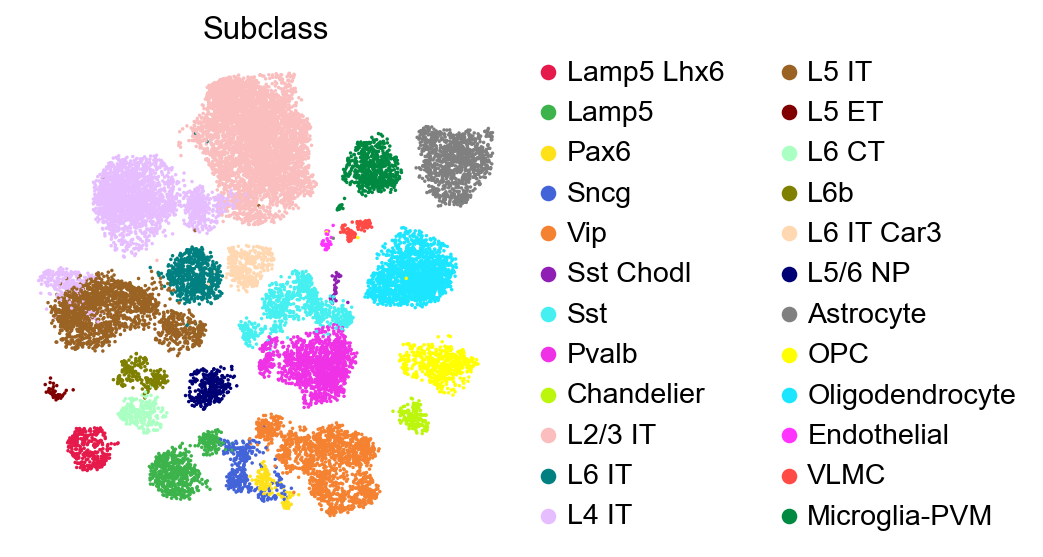

In [6]:
sc.pl.embedding(adata,
            basis='X_umap',
           color=['Subclass'],
           palette=self_palette2,
           legend_fontoutline=2,
           legend_fontweight=5,
           cmap='Spectral_r',
           ncols=3,
           size=10,
           frameon=False)

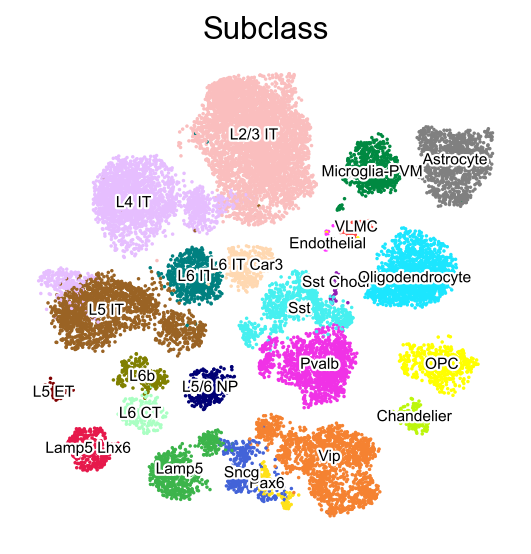

In [7]:
sc.pl.embedding(adata,
    basis='X_umap',
    color=['Subclass'],
    palette=self_palette2,
    legend_fontoutline=2,
    legend_fontsize=7,
    legend_fontweight=5,
    legend_loc='on data',
    cmap='Spectral_r',
    ncols=3,
    size=10,
    frameon=False)

The data is normalized, and the raw UMI counts were saved in `adata.layers['UMIs']`:

In [8]:
adata.X.data

array([0.8813792 , 2.510722  , 0.8813792 , ..., 0.37347588, 0.37347588,
       1.1829159 ], dtype=float32)

### Import COSG

Install the latest version of COSG via `pip install git+https://github.com/genecell/COSG.git` from https://github.com/genecell/COSG:

In [9]:
import cosg

In [10]:
%%time
groupby='Subclass'
cosg.cosg(adata,
    key_added='cosg',
    # use_raw=False, layer='log1p', ## e.g., if you want to use the log1p layer in adata
    mu=100,
    expressed_pct=0.1,
    remove_lowly_expressed=True,
    n_genes_user=adata.n_vars, ### Use all the genes, to enable the calculation of transformed COSG scores
    # n_genes_user=100,
    groupby=groupby,
    return_by_group=True, 
    verbosity=1
)

Finished identifying marker genes by COSG, and the results are in adata.uns['cosg'].
CPU times: user 7.92 s, sys: 3.15 s, total: 11.1 s
Wall time: 11.1 s


Let's visualize the top marker genes identified by COSG with dotplot. There are two ways to build a dendrogram, one with `use_rep` and one using the category orders in `adata.obs[groupby]`.

Here is the dotplot using the low-dimensional cell representations specified by `use_rep`:

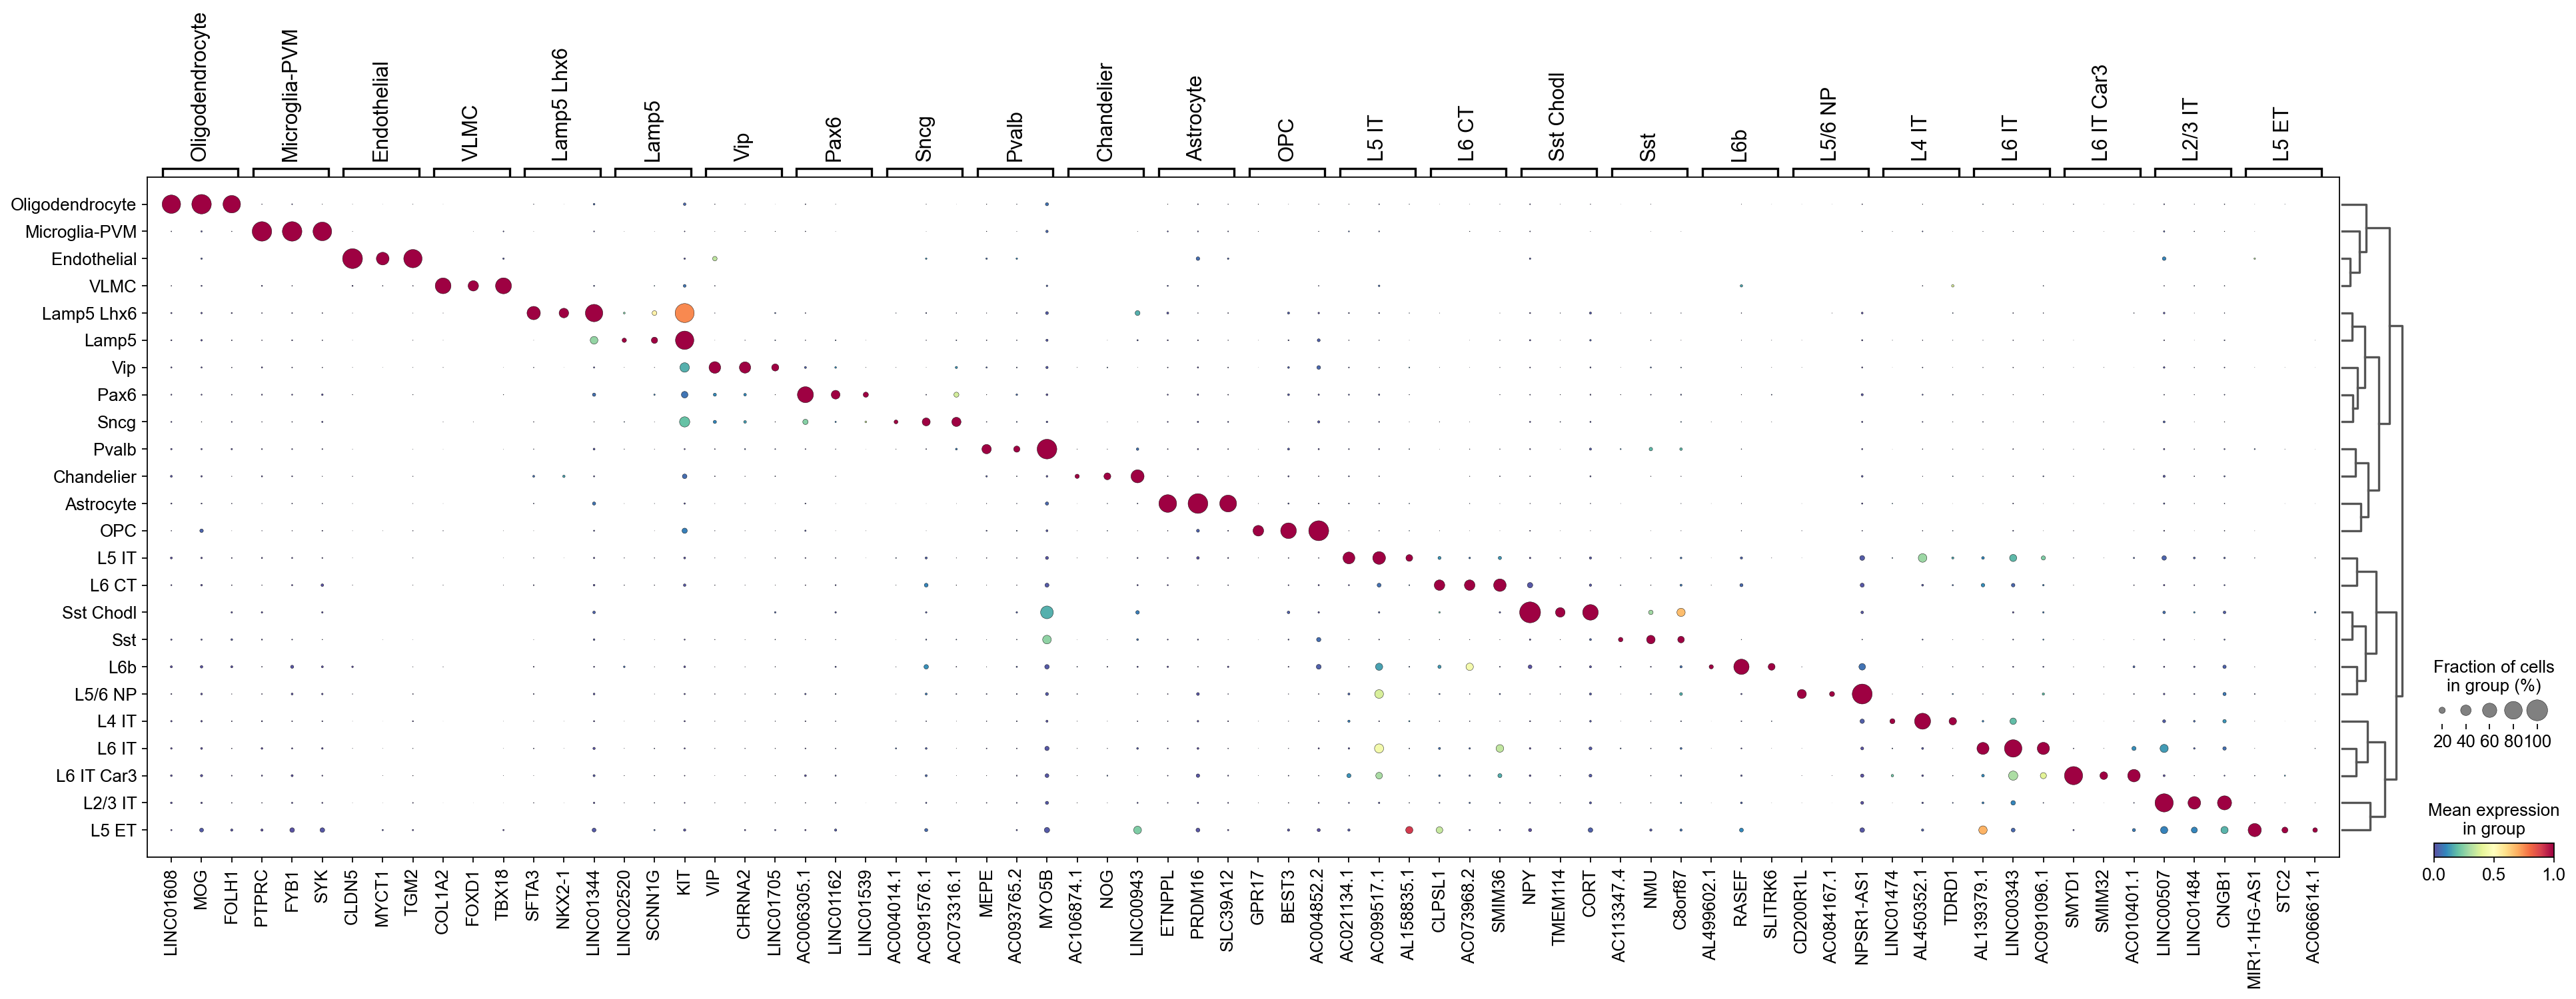

In [11]:
cosg.plotMarkerDotplot(
    adata,
    groupby='Subclass',
    top_n_genes=3,
    key_cosg='cosg',
    use_rep='X_scVI',
    swap_axes=False,
    standard_scale='var',
    cmap='Spectral_r',
    # save='test.pdf'
)

Use the category orders in `adata.obs[groupby]`:

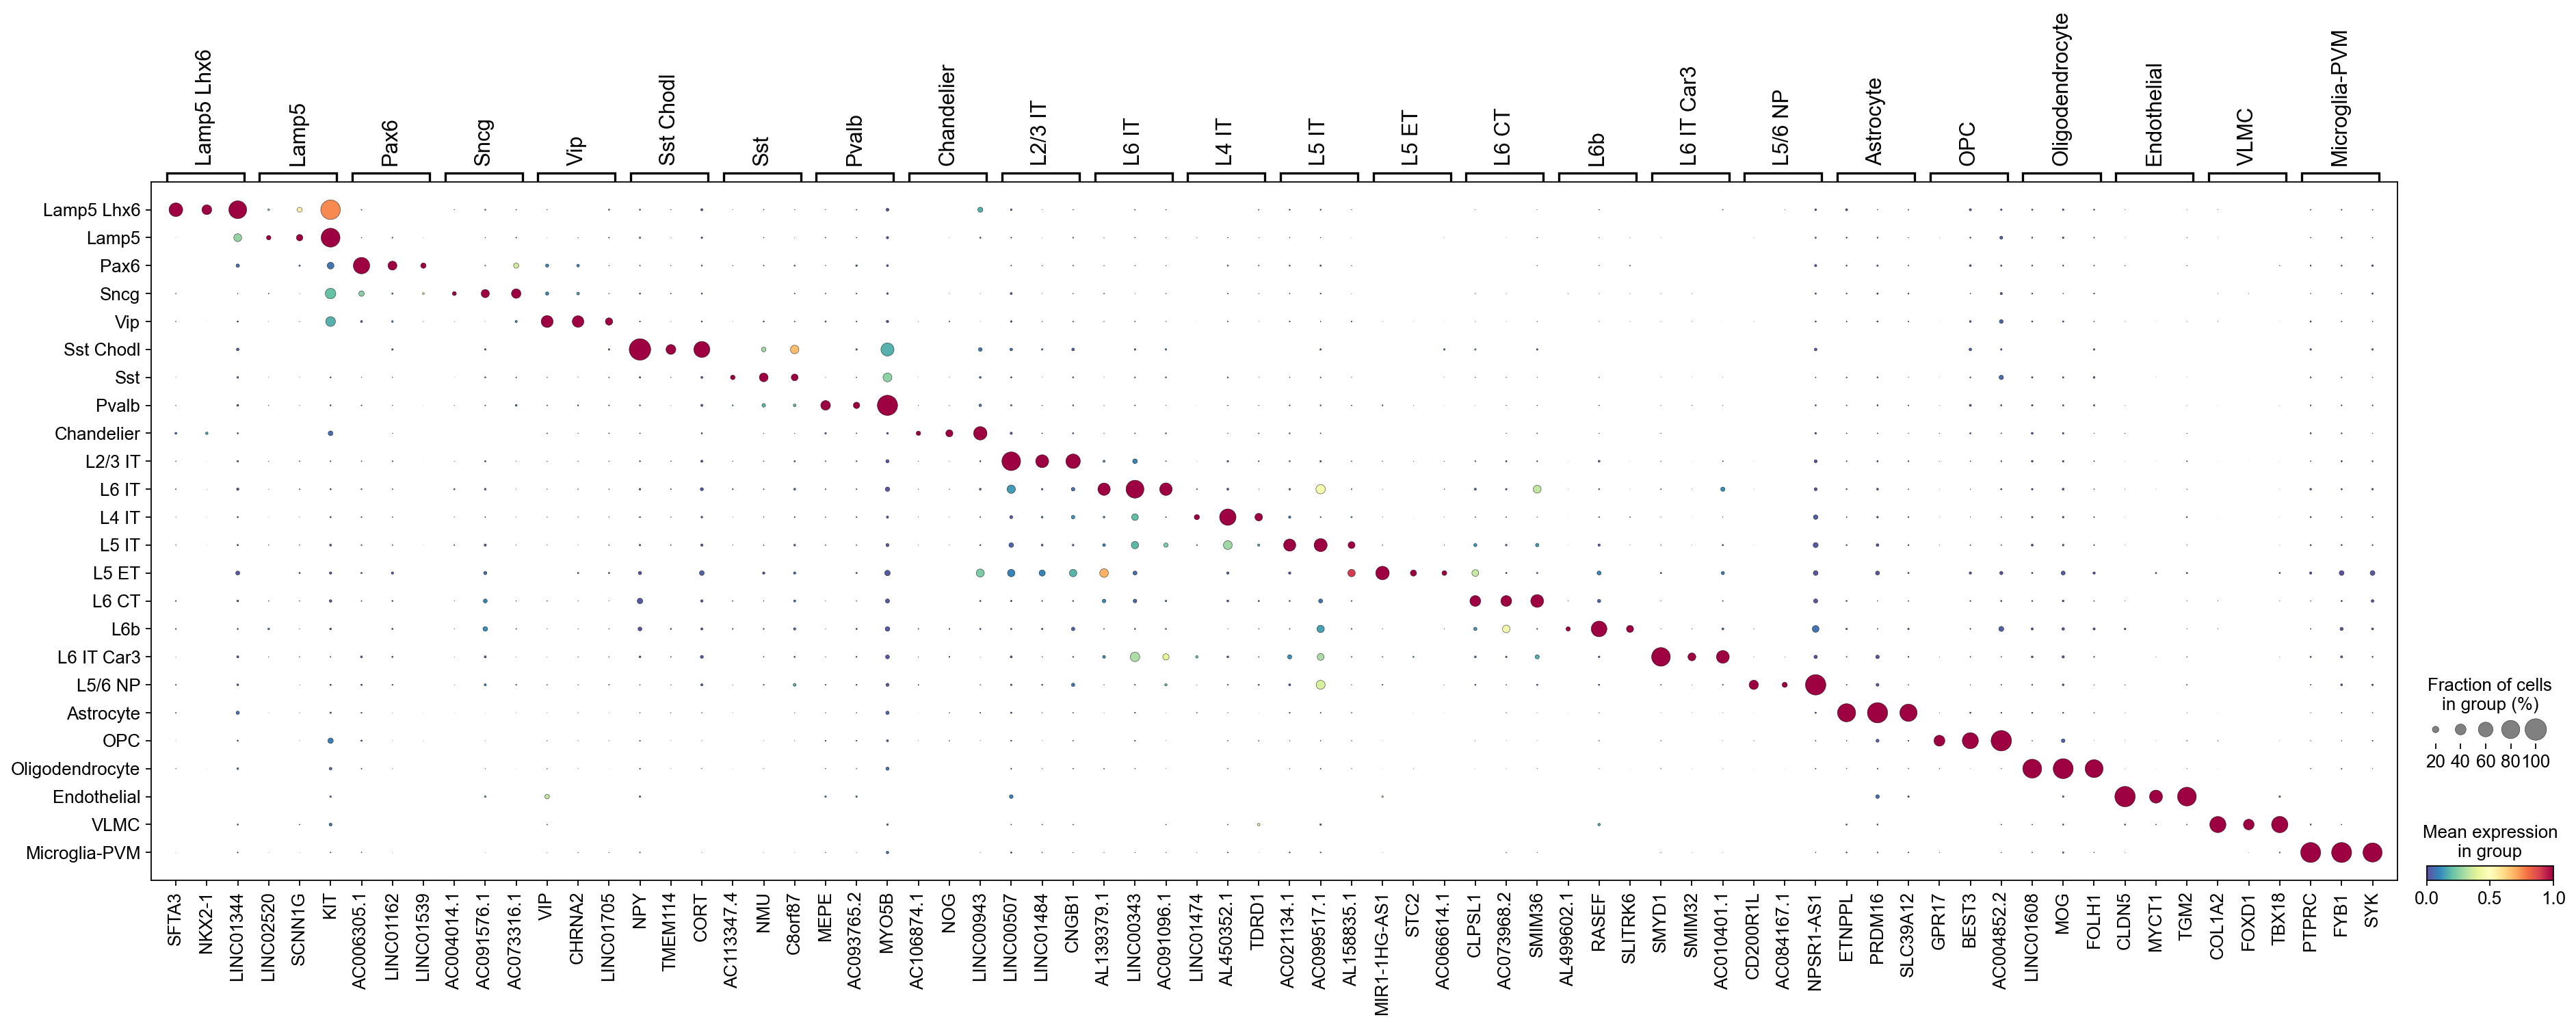

In [12]:
cosg.plotMarkerDotplot(
    adata,
    groupby='Subclass',
    top_n_genes=3,
    key_cosg='cosg',
    use_rep=None,
    swap_axes=False,
    standard_scale='var',
    cmap='Spectral_r',
    # save='test.pdf'
)

Check the top marker genes:

In [13]:
pd.DataFrame(adata.uns['cosg']['names']).head()

,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
0,SFTA3,LINC02520,AC006305.1,AC004014.1,VIP,NPY,AC113347.4,MEPE,AC106874.1,LINC00507,...,CLPSL1,AL499602.1,SMYD1,CD200R1L,ETNPPL,GPR17,LINC01608,CLDN5,COL1A2,PTPRC
1,NKX2-1,SCNN1G,LINC01162,AC091576.1,CHRNA2,TMEM114,NMU,AC093765.2,NOG,LINC01484,...,AC073968.2,RASEF,SMIM32,AC084167.1,PRDM16,BEST3,MOG,MYCT1,FOXD1,FYB1
2,LINC01344,KIT,LINC01539,AC073316.1,LINC01705,CORT,C8orf87,MYO5B,LINC00943,CNGB1,...,SMIM36,SLITRK6,AC010401.1,NPSR1-AS1,SLC39A12,AC004852.2,FOLH1,TGM2,TBX18,SYK
3,AL355482.1,AC099482.2,ABCB5,AL161629.1,AJ006995.1,GHRH,LINC02133,LRRC38,AC006065.4,AC008574.1,...,KL,SCUBE1,AC073225.1,LINC02042,OBI1-AS1,LINC01546,CD22,SRARP,C7,IKZF1
4,HCRTR2,CPLX3,LINC01416,AC004862.1,NPR3,DDC,OTOF,AC006364.1,SCUBE3,LINC02714,...,AC092114.1,FIBCD1,DCSTAMP,NPSR1,SLC14A1,VCAN-AS1,SLCO1A2,FENDRR,FMO2,PIK3R5


Check the corrsponding COSG scores:

In [14]:
pd.DataFrame(adata.uns['cosg']['scores']).head()

,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
0,0.292173,0.058870,0.028365,0.068951,0.350845,0.381491,0.095953,0.362747,0.053039,0.527400,...,0.013717,0.105420,0.668806,0.431743,0.767967,0.450832,0.832948,0.801609,0.763216,0.871644
1,0.231243,0.019967,0.012673,0.068790,0.328894,0.053314,0.049051,0.172069,0.028827,0.482379,...,0.009300,0.068174,0.173390,0.327094,0.763356,0.419320,0.806407,0.573506,0.584916,0.856651
2,0.026953,0.017913,0.006920,0.019831,0.268984,0.011365,0.021399,0.126399,0.024365,0.317597,...,0.006055,0.067735,0.093702,0.283468,0.725767,0.351603,0.799328,0.571553,0.583440,0.834092
3,0.013707,0.016702,0.003892,0.016700,0.262942,0.008558,0.020437,0.117930,0.022924,0.264376,...,0.004044,0.040743,0.092139,0.157058,0.698517,0.310609,0.772911,0.567358,0.469173,0.822119
4,0.011856,0.015210,0.003594,0.012816,0.254974,0.007424,0.013169,0.033898,0.020663,0.204915,...,0.003518,0.025265,0.068585,0.111516,0.687068,0.297090,0.761675,0.554236,0.429890,0.819302


The COSG results are also saved as a multi-index Pandas dataframe format if you set `return_by_group=True` (by default), and you can access it via:

In [15]:
adata.uns['cosg']['COSG'].head()

,names,scores,names,scores,names,scores,names,scores,names,scores,...,names,scores,names,scores,names,scores,names,scores,names,scores
,Lamp5 Lhx6,Lamp5 Lhx6,Lamp5,Lamp5,Pax6,Pax6,Sncg,Sncg,Vip,Vip,...,OPC,OPC,Oligodendrocyte,Oligodendrocyte,Endothelial,Endothelial,VLMC,VLMC,Microglia-PVM,Microglia-PVM
0,SFTA3,0.292173,LINC02520,0.058870,AC006305.1,0.028365,AC004014.1,0.068951,VIP,0.350845,...,GPR17,0.450832,LINC01608,0.832948,CLDN5,0.801609,COL1A2,0.763216,PTPRC,0.871644
1,NKX2-1,0.231243,SCNN1G,0.019967,LINC01162,0.012673,AC091576.1,0.068790,CHRNA2,0.328894,...,BEST3,0.419320,MOG,0.806407,MYCT1,0.573506,FOXD1,0.584916,FYB1,0.856651
2,LINC01344,0.026953,KIT,0.017913,LINC01539,0.006920,AC073316.1,0.019831,LINC01705,0.268984,...,AC004852.2,0.351603,FOLH1,0.799328,TGM2,0.571553,TBX18,0.583440,SYK,0.834092
3,AL355482.1,0.013707,AC099482.2,0.016702,ABCB5,0.003892,AL161629.1,0.016700,AJ006995.1,0.262942,...,LINC01546,0.310609,CD22,0.772911,SRARP,0.567358,C7,0.469173,IKZF1,0.822119
4,HCRTR2,0.011856,CPLX3,0.015210,LINC01416,0.003594,AC004862.1,0.012816,NPR3,0.254974,...,VCAN-AS1,0.297090,SLCO1A2,0.761675,FENDRR,0.554236,FMO2,0.429890,PIK3R5,0.819302


Similarly, you could extract the names or scores by:

In [16]:
adata.uns['cosg']['COSG']['names'].head()

,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
0,SFTA3,LINC02520,AC006305.1,AC004014.1,VIP,NPY,AC113347.4,MEPE,AC106874.1,LINC00507,...,CLPSL1,AL499602.1,SMYD1,CD200R1L,ETNPPL,GPR17,LINC01608,CLDN5,COL1A2,PTPRC
1,NKX2-1,SCNN1G,LINC01162,AC091576.1,CHRNA2,TMEM114,NMU,AC093765.2,NOG,LINC01484,...,AC073968.2,RASEF,SMIM32,AC084167.1,PRDM16,BEST3,MOG,MYCT1,FOXD1,FYB1
2,LINC01344,KIT,LINC01539,AC073316.1,LINC01705,CORT,C8orf87,MYO5B,LINC00943,CNGB1,...,SMIM36,SLITRK6,AC010401.1,NPSR1-AS1,SLC39A12,AC004852.2,FOLH1,TGM2,TBX18,SYK
3,AL355482.1,AC099482.2,ABCB5,AL161629.1,AJ006995.1,GHRH,LINC02133,LRRC38,AC006065.4,AC008574.1,...,KL,SCUBE1,AC073225.1,LINC02042,OBI1-AS1,LINC01546,CD22,SRARP,C7,IKZF1
4,HCRTR2,CPLX3,LINC01416,AC004862.1,NPR3,DDC,OTOF,AC006364.1,SCUBE3,LINC02714,...,AC092114.1,FIBCD1,DCSTAMP,NPSR1,SLC14A1,VCAN-AS1,SLCO1A2,FENDRR,FMO2,PIK3R5


### Calculate normalized COSG scores for each gene across all cell types

In addition to COSG scores, the normalized COSG scores (or the transformed COSG scores) can also be calculated to enable cross-cell type comparison of the gene expression specificities. This could also potentially enables the expression specificity comparison across datasets or stuides.

Note: setting `n_genes_user = adata.n_vars` in the `cosg.cosg()` function is required for calculation of normalized COSG scores.

We firstly reindex the marker gene dataframes by indexing them with the same gene indexes, and the values are the COSG scores in each cell type:

In [17]:
cosg_scores=cosg.indexByGene(
    adata.uns['cosg']['COSG'],
    # gene_key="names", score_key="scores",
    set_nan_to_zero=True,
    convert_negative_one_to_zero=True
)

In [18]:
cosg_scores.head()

,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
SFTA3,0.292173,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NKX2-1,0.231243,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LINC01344,0.026953,0.000317,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL355482.1,0.013707,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HCRTR2,0.011856,0.000000,0.000058,0.000023,0.0,0.0,0.0,0.0,0.0,0.000028,...,0.000035,0.000153,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Next, we normalize the COSG scores:

In [19]:
cosg_scores=cosg.iqrLogNormalize(cosg_scores)

In [20]:
cosg_scores.head()

,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
SFTA3,9.762279,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NKX2-1,9.528420,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LINC01344,7.379579,2.019498,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL355482.1,6.703997,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HCRTR2,6.559136,0.000000,2.468799,0.862006,0.0,0.0,0.0,0.0,0.0,0.017969,...,1.405817,2.548247,0.05476,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Let's check some genes' normalized scores:

In [21]:
gene_check=np.ravel(pd.DataFrame(adata.uns['cosg']['names'])[:1].values.T)[:5]

In [22]:
cosg_scores.loc[gene_check].T.head()

,SFTA3,LINC02520,AC006305.1,AC004014.1,VIP
Lamp5 Lhx6,9.762279,0.000000,0.000000,0.000000,0.00000
Lamp5,0.000000,7.103147,0.000000,0.000000,0.00000
Pax6,0.000000,0.000000,8.580213,0.000000,0.00000
Sncg,0.000000,0.000000,2.847808,8.320658,0.00000
Vip,0.000000,0.000000,0.000000,0.000000,7.59415


and here are the COSG scores before normalization, which are not directly comparable across cell types, as they are influenced by the cell numbers and cell cluster similarities, etc.

In [23]:
cosg_scores_original=cosg.indexByGene(
    adata.uns['cosg']['COSG'],
    # gene_key="names", score_key="scores",
    set_nan_to_zero=True,
    convert_negative_one_to_zero=True
)
cosg_scores_original.loc[gene_check].T.head()

,SFTA3,LINC02520,AC006305.1,AC004014.1,VIP
Lamp5 Lhx6,0.292173,0.00000,0.000000,0.000000,0.000000
Lamp5,0.000000,0.05887,0.000000,0.000000,0.000000
Pax6,0.000000,0.00000,0.028365,0.000000,0.000000
Sncg,0.000000,0.00000,0.000273,0.068951,0.000000
Vip,0.000000,0.00000,0.000000,0.000000,0.350845


### Visualizing the marker genes with plotMarkerDendrogram

COSG provides an intutive visualization with marker gene names, COSG scores and cell cluster similarities:

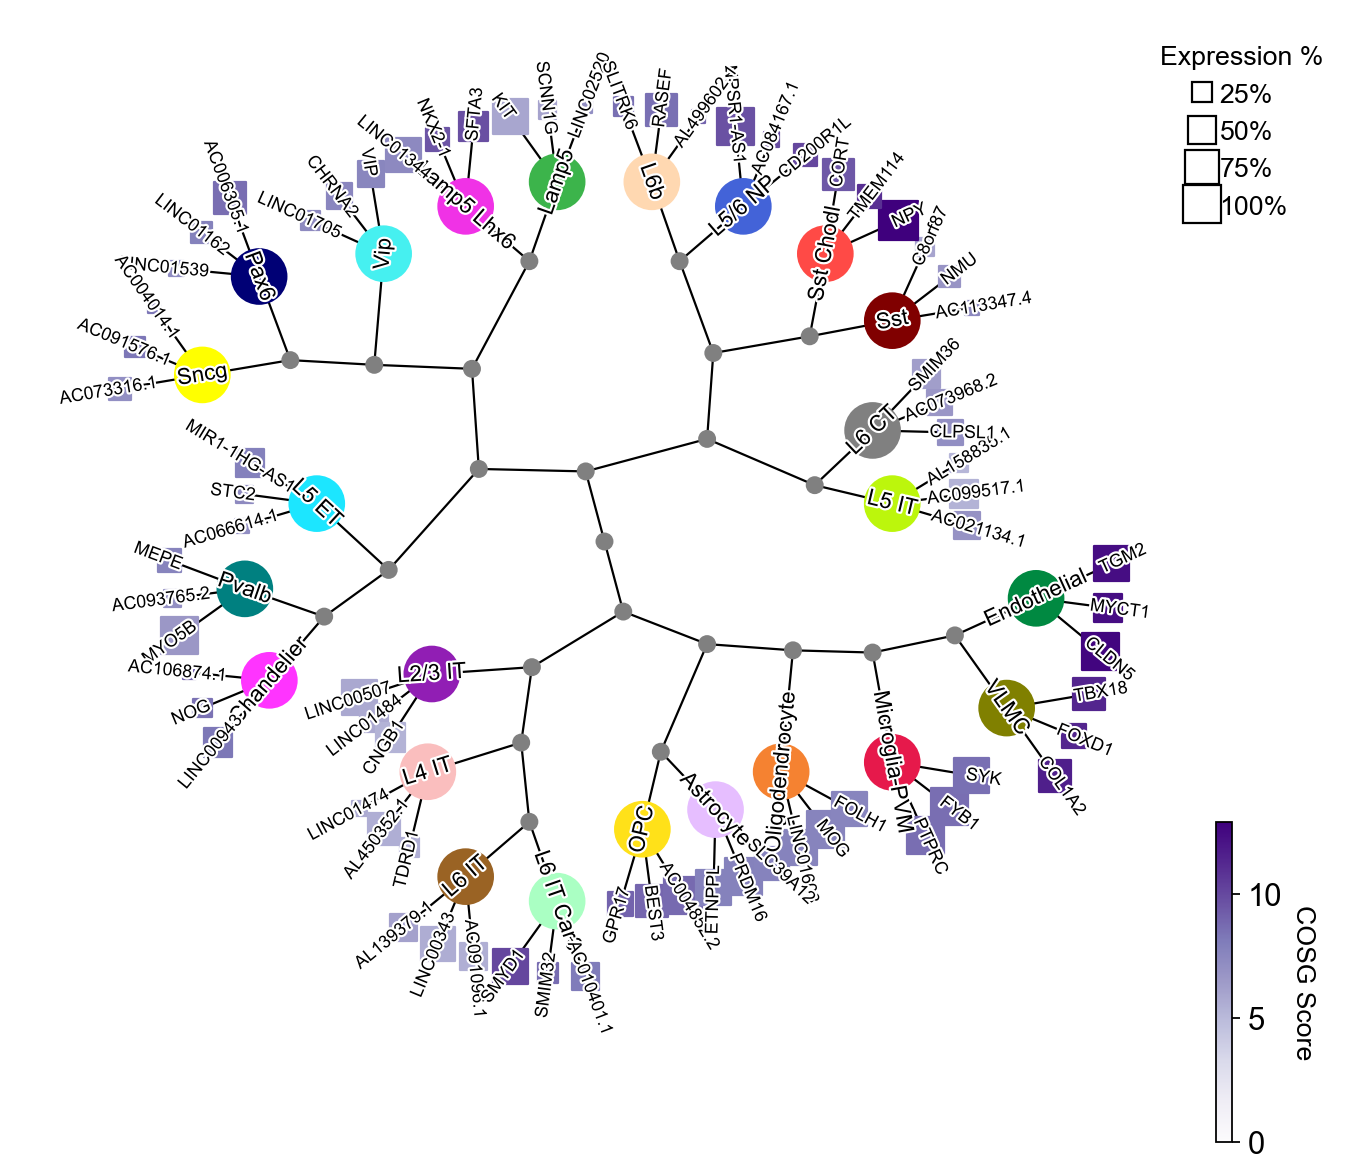

In [24]:
cosg.plotMarkerDendrogram(
     adata,
     group_by="Subclass",
     use_rep="X_scVI",
     calculate_dendrogram_on_cosg_scores=False,
     top_n_genes=3,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     # collapse_scale=0.2,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # node_shape_cell_type='o',
     # node_shape_gene='s', 
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

You could set the gene node colors by `cmap` and merge the hierarchical dendrogram by `hierarchy_merge_scale`. The parameter `hierarchy_merge_scale` (0 to 1) controls merging binary nodes into multi-child nodes based on distance similarity:

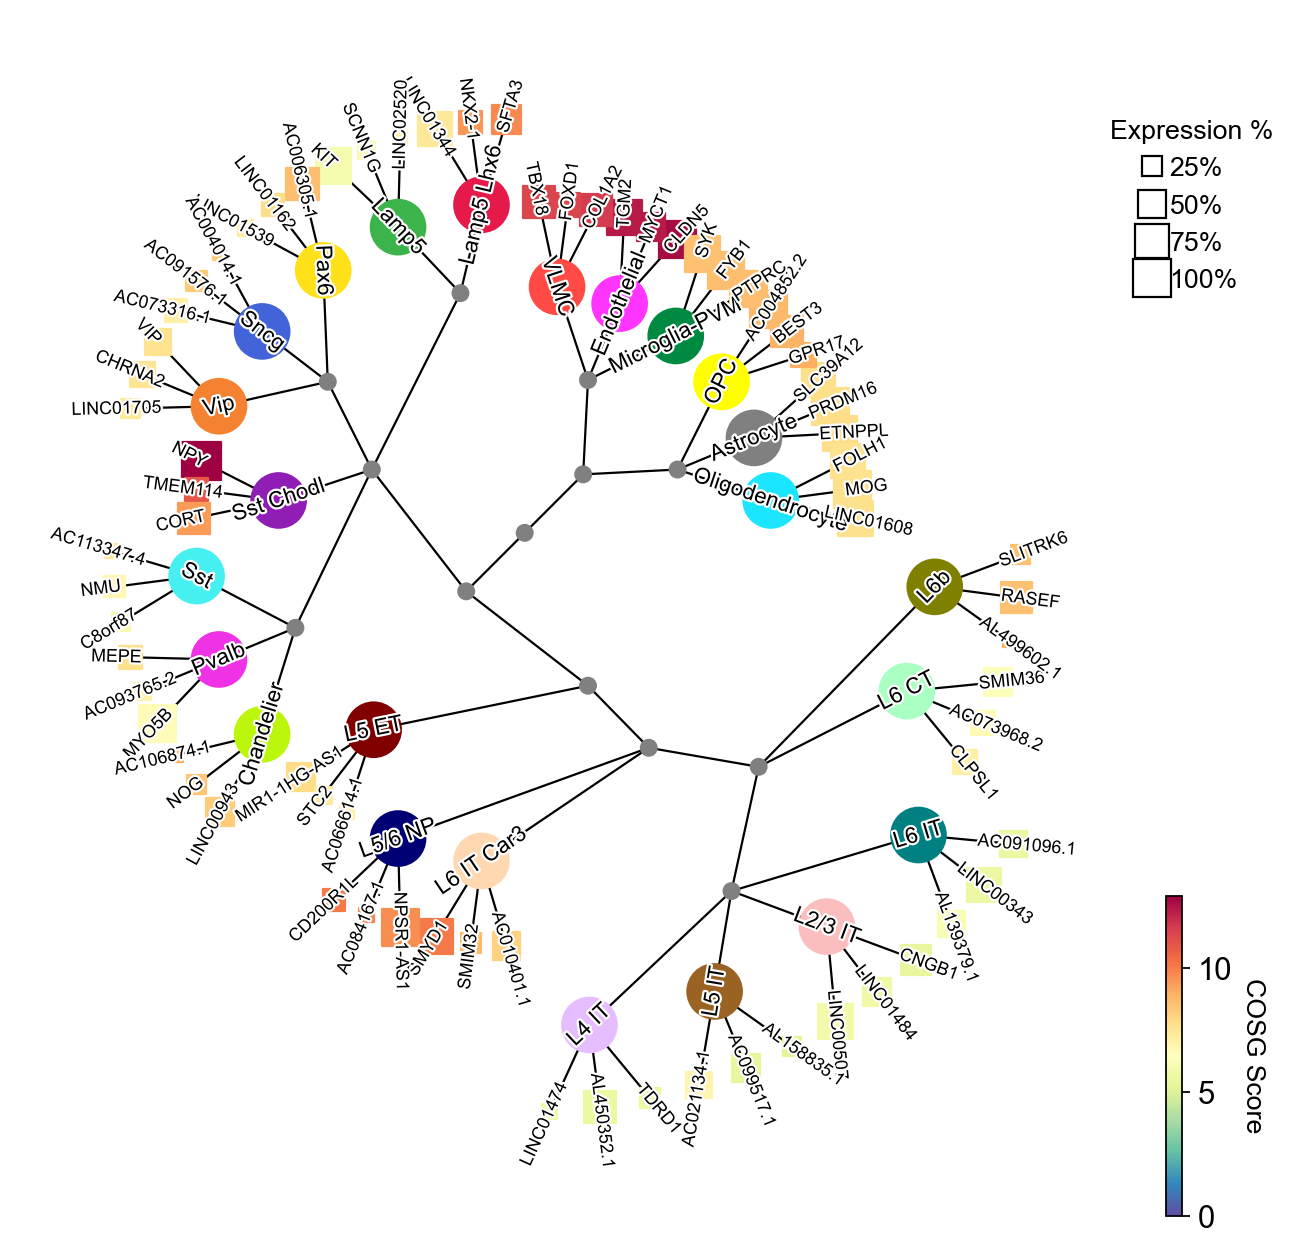

In [25]:
cosg.plotMarkerDendrogram(
     adata,
     group_by="Subclass",
     use_rep="X_scVI",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=3,
     radius_step=1.5,
     cmap="Spectral_r",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0.2,
     # collapse_scale=0.2,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # figure_size= (8, 8),
     # node_shape_cell_type='o',
     # node_shape_gene='s', 
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

You could also collapse the dendrogram by setting `collapse_scale` to a value between 0 and 1:

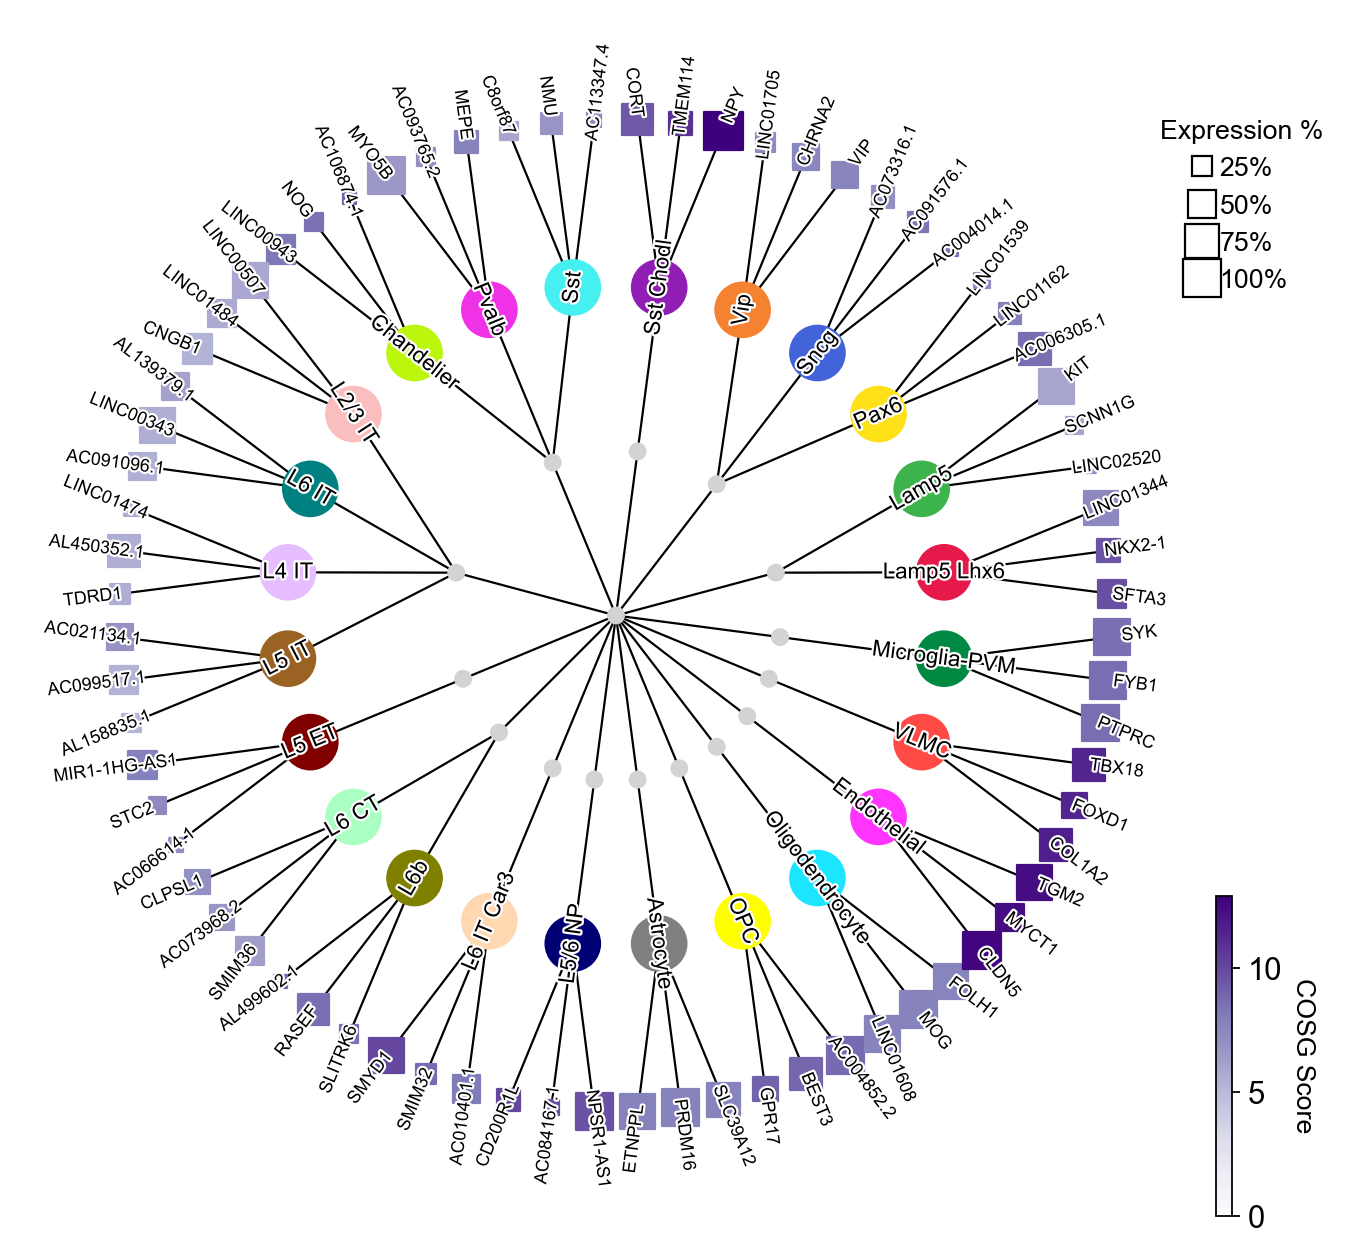

In [26]:
cosg.plotMarkerDendrogram(
     adata,
     group_by="Subclass",
     use_rep="X_scVI",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=3,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     collapse_scale=0.2,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # node_shape_cell_type='o',
     # node_shape_gene='s', 
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

The parameter `collapse_scale` controls the clustering resolution of cell types, larger values lead to more clusters:

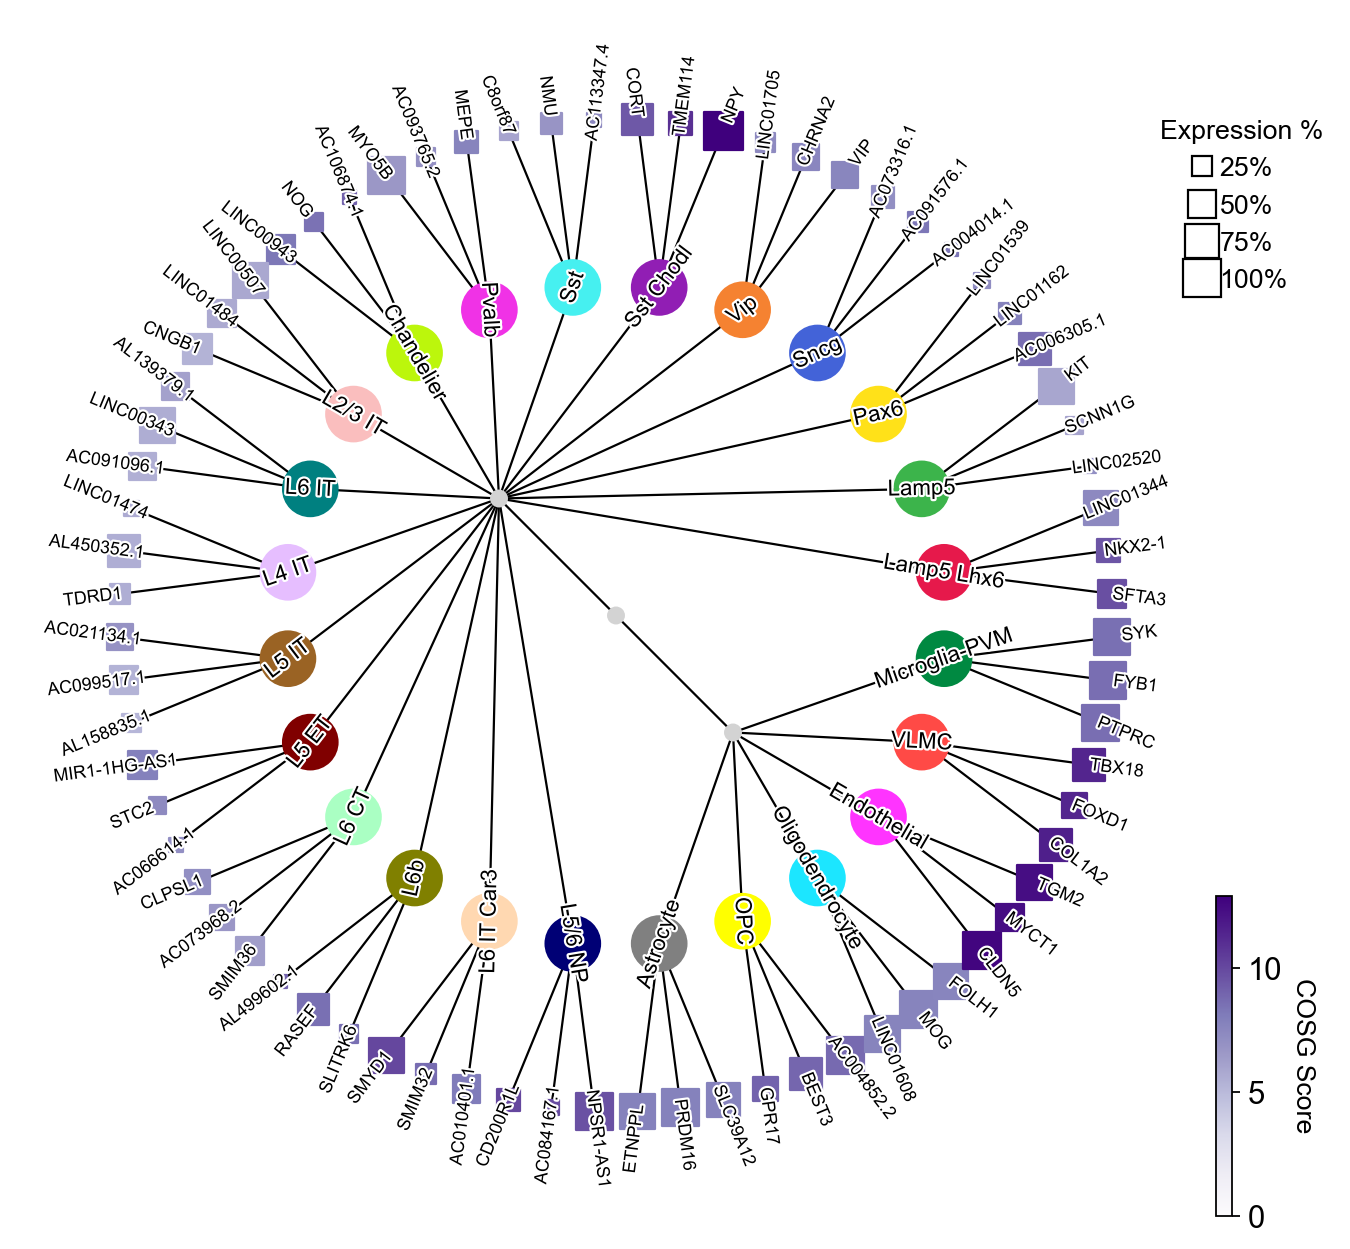

In [27]:
cosg.plotMarkerDendrogram(
     adata,
     group_by="Subclass",
     use_rep="X_scVI",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=3,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     collapse_scale=0.8,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # node_shape_cell_type='o',
     # node_shape_gene='s', 
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

Besides, you could also not show the figure by setting `show_figure=False` and save the figure as a PDF file by `save='./markerDendrogram.pdf'`:

In [28]:
cosg.plotMarkerDendrogram(
     adata,
     group_by="Subclass",
     use_rep="X_scVI",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=3,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     collapse_scale=0.2,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # node_shape_cell_type='o',
     # node_shape_gene='s', 
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=False,
     # save='./markerDendrogram.pdf',
)

The shape of cell type nodes and gene nodes could be adjusted via `node_shape_cell_type` and `node_shape_gene`, respectively:

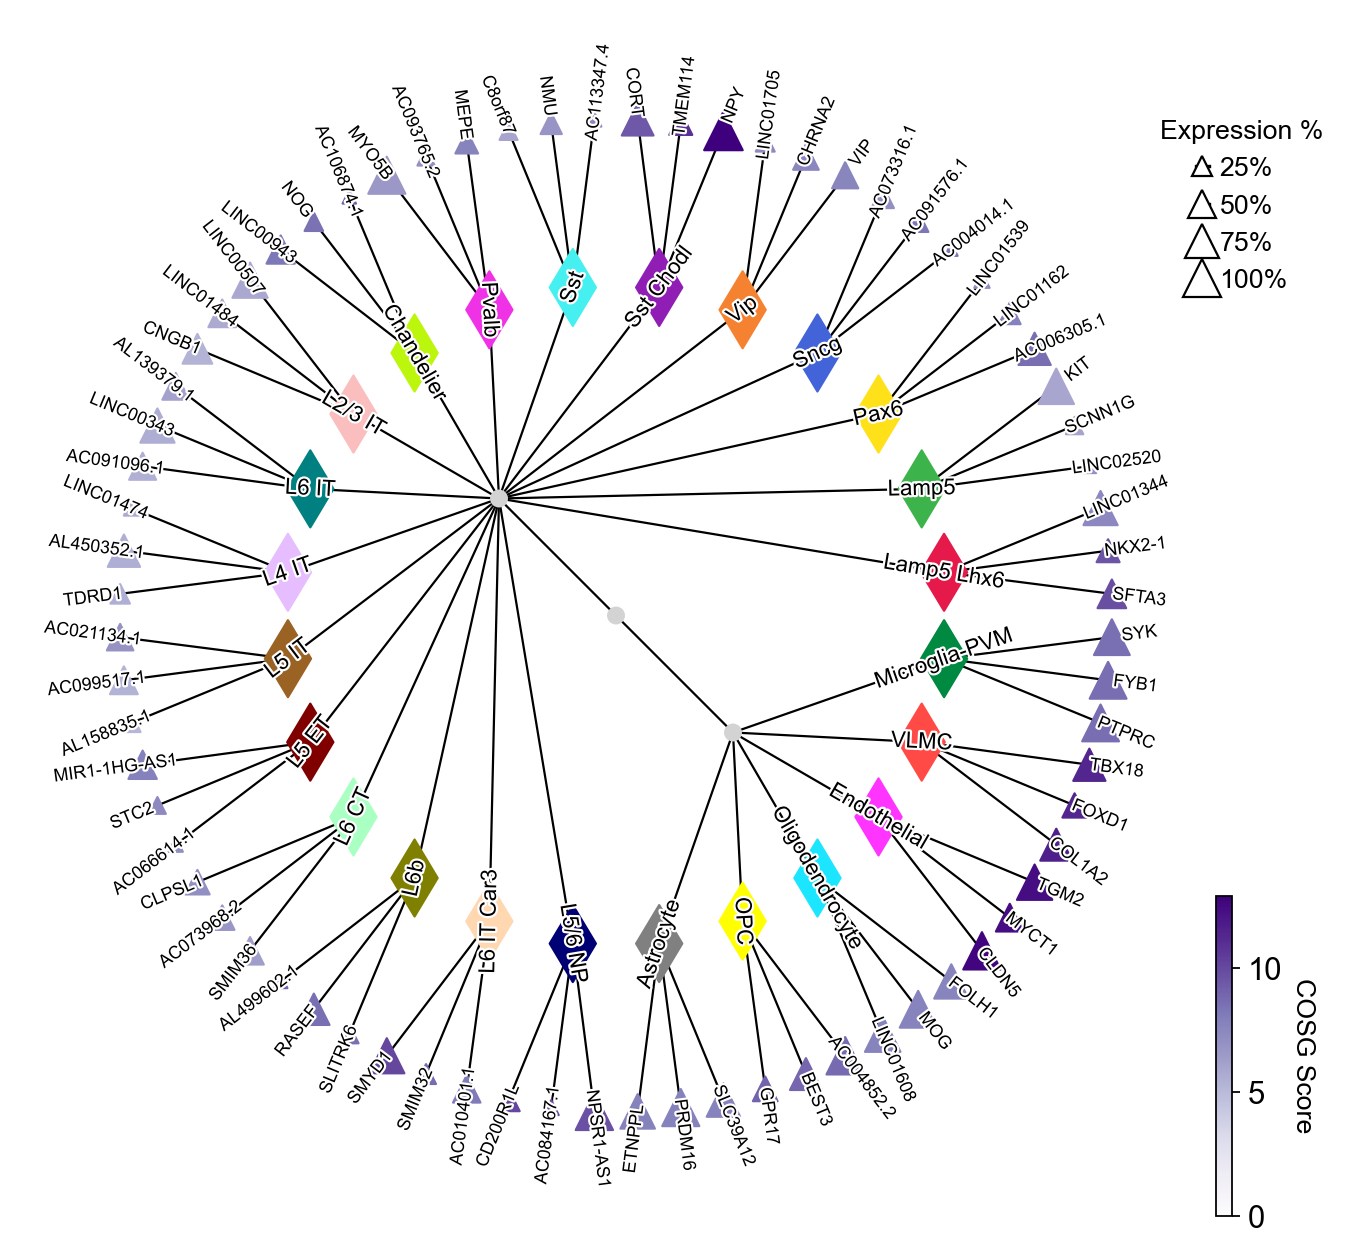

In [29]:
cosg.plotMarkerDendrogram(
     adata,
     group_by="Subclass",
     use_rep="X_scVI",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=3,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     collapse_scale=0.8,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     node_shape_cell_type='d',
     node_shape_gene='^', 
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

### Run COSG with assigned `batch_key`

In this example dataset, the cells are divided into two groups based on whther the donors are severly affected, and the information is in the `Severely Affected Donor` column:

In [30]:
pd.crosstab(adata.obs['Severely Affected Donor'], adata.obs['Subclass'])

Subclass,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
Severely Affected Donor,,,,,,,,,,,,,,,,,,,,,
N,285,598,134,312,1463,31,752,1246,146,4635,...,221,212,319,286,917,467,1578,26,77,563
Y,20,55,6,17,88,0,28,53,11,191,...,10,12,35,13,163,29,85,5,9,75


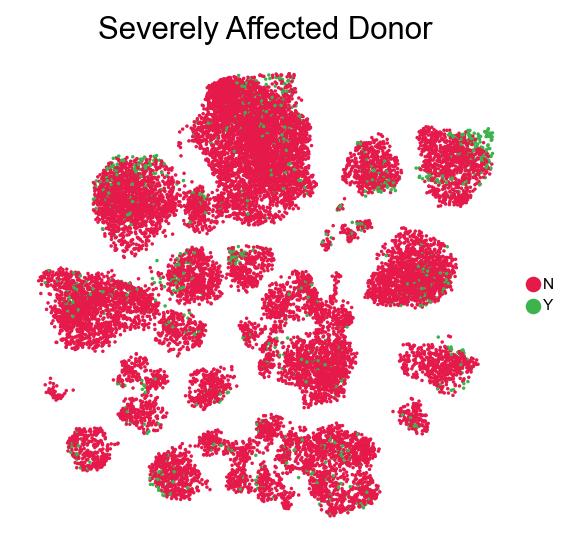

In [31]:
sc.pl.embedding(adata,
    basis='X_umap',
    color=['Severely Affected Donor'],
    palette=self_palette2,
    legend_fontoutline=2,
    legend_fontsize=7,
    legend_fontweight=5,
    # legend_loc='on data',
    # cmap='Spectral_r',
    ncols=3,
    size=10,
    frameon=False)

We could run COSG with `batch_key` set as "Severely Affected Donor", computing cosine similarities separately for each batch before averaging them. The COSG scores were then derived from these averaged similarities.

In [32]:
%%time
groupby='Subclass'
cosg.cosg(adata,
    key_added='cosg_batch',
    # use_raw=False, layer='log1p', ## e.g., if you want to use the log1p layer in adata
    mu=100,
    batch_key='Severely Affected Donor', ### Set the batch key
    batch_cell_number_threshold=5, ### Minimum number of cells required in a batch for a given cluster to be considered 
    expressed_pct=0.1,
    remove_lowly_expressed=True, 
    n_genes_user=adata.n_vars, ### Use all the genes, to enable the calculation of transformed COSG scores
    # n_genes_user=100, 
    groupby=groupby,
    return_by_group=True, 
    verbosity=1
)

Finished identifying marker genes by COSG, and the results are in adata.uns['cosg_batch'].
CPU times: user 8.28 s, sys: 3.49 s, total: 11.8 s
Wall time: 11.8 s


In [33]:
pd.DataFrame(adata.uns['cosg_batch']['names']).head()

,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
0,NKX2-1,LINC02520,AC006305.1,AC004014.1,LINC01705,NPY,NMU,MEPE,AC006065.4,LINC00507,...,CLPSL1,AL499602.1,SMYD1,AC084167.1,PRDM16,AC004852.2,LINC01608,CLDN5,COL1A2,PTPRC
1,SFTA3,SCNN1G,NTF3,AC091576.1,VIP,TMEM114,AC113347.4,MYO5B,AC106874.1,LINC01484,...,AC073968.2,AL357509.1,DCSTAMP,NPSR1-AS1,OBI1-AS1,GPR17,FOLH1,TGM2,TBX18,SYK
2,LINC01344,CPLX3,AL139090.1,AC073316.1,AJ006995.1,GHRH,LINC02133,AC093765.2,SCUBE3,AC008574.1,...,AC127459.2,RASEF,SMIM32,LINC02543,SLC39A12,BEST3,CD22,MYCT1,FMO2,FYB1
3,HCRTR2,AC099482.2,RELN,AL161629.1,LINC02257,SST,C8orf87,LRRC38,LINC00943,CNGB1,...,AC092114.1,LINC01654,AC010401.1,NPSR1,ETNPPL,FERMT1,MOG,CD34,FOXD1,IKZF1
4,MYB,KIT,LINC01539,LINC02408,NPR3,CORT,PAWR,SULF1,NOG,LINC02714,...,SEMA3E,AL596257.1,TRPC7-AS1,CD200R1L,SLC14A1,AC007106.1,SH3TC2,PCAT19,C7,DOCK8


and here are the COSG results without `batch_key` assigned:

In [34]:
pd.DataFrame(adata.uns['cosg']['names']).head()

,Lamp5 Lhx6,Lamp5,Pax6,Sncg,Vip,Sst Chodl,Sst,Pvalb,Chandelier,L2/3 IT,...,L6 CT,L6b,L6 IT Car3,L5/6 NP,Astrocyte,OPC,Oligodendrocyte,Endothelial,VLMC,Microglia-PVM
0,SFTA3,LINC02520,AC006305.1,AC004014.1,VIP,NPY,AC113347.4,MEPE,AC106874.1,LINC00507,...,CLPSL1,AL499602.1,SMYD1,CD200R1L,ETNPPL,GPR17,LINC01608,CLDN5,COL1A2,PTPRC
1,NKX2-1,SCNN1G,LINC01162,AC091576.1,CHRNA2,TMEM114,NMU,AC093765.2,NOG,LINC01484,...,AC073968.2,RASEF,SMIM32,AC084167.1,PRDM16,BEST3,MOG,MYCT1,FOXD1,FYB1
2,LINC01344,KIT,LINC01539,AC073316.1,LINC01705,CORT,C8orf87,MYO5B,LINC00943,CNGB1,...,SMIM36,SLITRK6,AC010401.1,NPSR1-AS1,SLC39A12,AC004852.2,FOLH1,TGM2,TBX18,SYK
3,AL355482.1,AC099482.2,ABCB5,AL161629.1,AJ006995.1,GHRH,LINC02133,LRRC38,AC006065.4,AC008574.1,...,KL,SCUBE1,AC073225.1,LINC02042,OBI1-AS1,LINC01546,CD22,SRARP,C7,IKZF1
4,HCRTR2,CPLX3,LINC01416,AC004862.1,NPR3,DDC,OTOF,AC006364.1,SCUBE3,LINC02714,...,AC092114.1,FIBCD1,DCSTAMP,NPSR1,SLC14A1,VCAN-AS1,SLCO1A2,FENDRR,FMO2,PIK3R5
